Contexte 
Une entreprise souhaite développer un système d’intelligence artificielle capable de reconnaître 
automatiquement le type de déchet présent sur une photographie afin d'améliorer le tri des 
déchets. 
Le modèle devra classer chaque image dans l'une des catégories suivantes : 

 cardboard : cartons ondulés, cartons plats, … 

 plastic : bouteilles, emballages plastiques... 

 paper : feuilles,  journaux... 

 glass : bouteilles et objets en verre... 

 metal : canettes, boîtes métalliques... 

 trash : emballages bonbons, tasses jetables, ... 
 
Le problème est que les images collectées proviennent de plusieurs sources. Elles ne sont donc pas 
homogènes : dimensions différentes ; formats différents ; images RGB et grayscale ; certaines images 
sont trop petites ; certaines images sont corrompues ; quelques images sont vides ; images 
dupliquées ; quelques images placées dans le mauvais dossier ; classes déséquilibrées. 
L'objectif de l'atelier est donc de construire un jeu de données images propre et homogène, prêt à 
être utilisé pour entraîner un modèle de Machine Learning ou de Deep Learning. 

Partie 1 –
 Exploration du dataset 
Développer un programme Python capable de récupérer, pour chaque image, son nom, sa classe, 
son format, son mode, sa largeur, sa hauteur, l’écart-type de ses pixels, son nombre de canaux et sa 
taille. 
NB : prendre en charge aussi les fichiers corrompus 

In [10]:
import glob
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

RAW_DIR = "../data/raw"
CLEAN_DIR = "../data/cleaned"
REPORTS_DIR = "../reports"

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# Nombre de fichiers par classe
total = 0
for classe in CLASSES:
    fichiers = glob.glob(f"{RAW_DIR}/{classe}/*")
    total += len(fichiers)
    print(f"{classe:10s} : {len(fichiers)}")
print("Total fichiers :", total)

cardboard  : 169
glass      : 188
metal      : 149
paper      : 252
plastic    : 224
trash      : 50
Total fichiers : 1032


In [ ]:
def lire_image(chemin, classe):
    """Retourne un dictionnaire d'infos sur une image (corrompue ou non)."""
    info = {
        "nom": chemin.replace("\\", "/").split("/")[-1],
        "classe": classe,
        "chemin": chemin,
        "format": None,
        "mode": None,
        "largeur": None,
        "hauteur": None,
        "std_pixels": None,
        "nb_canaux": None,
        "taille_octets": None,
        "corrompue": False,
        "erreur": None,
    }

    # Taille du fichier en octets (sans os) : on va à la fin du fichier
    with open(chemin, "rb") as f:
        f.seek(0, 2)
        info["taille_octets"] = f.tell()

    try:
        with Image.open(chemin) as img:
            info["format"] = img.format
            info["mode"] = img.mode
            info["largeur"], info["hauteur"] = img.size
            info["nb_canaux"] = len(img.getbands())
            # np.array force le décodage complet : une image tronquée lèvera une erreur ici
            pixels = np.array(img.convert("L"), dtype=float)
            info["std_pixels"] = pixels.std()
    except Exception as e:
        info["corrompue"] = True
        info["erreur"] = str(e)

    return info


lignes = []
for classe in CLASSES:
    for chemin in sorted(glob.glob(f"{RAW_DIR}/{classe}/*")):
        lignes.append(lire_image(chemin, classe))

df = pd.DataFrame(lignes)
print(df.shape)
df.head()

(1032, 12)


,nom,classe,chemin,format,mode,largeur,hauteur,std_pixels,nb_canaux,taille_octets,corrompue,erreur
0,cardboard1.jpg,cardboard,../data/raw/cardboard\cardboard1.jpg,JPEG,RGB,512.0,384.0,31.875892,3.0,17333,False,NaN
1,cardboard10.jpg,cardboard,../data/raw/cardboard\cardboard10.jpg,JPEG,RGB,512.0,384.0,38.799907,3.0,21683,False,NaN
2,cardboard100.jpg,cardboard,../data/raw/cardboard\cardboard100.jpg,JPEG,RGB,512.0,384.0,44.498372,3.0,14884,False,NaN
3,cardboard101.jpg,cardboard,../data/raw/cardboard\cardboard101.jpg,JPEG,RGB,512.0,384.0,68.561937,3.0,14289,False,NaN
4,cardboard102.jpg,cardboard,../data/raw/cardboard\cardboard102.jpg,JPEG,RGB,512.0,384.0,45.320633,3.0,18015,False,NaN


: 

Partie 2 – Détecter les images corrompues 
Écrire et se servir d’une fonction qui détecte une image corrompue. 

In [ ]:
def est_corrompue(chemin):
    """True si l'image ne peut pas être ouverte et décodée entièrement."""
    try:
        with Image.open(chemin) as img:
            img.verify()          # contrôle de la structure du fichier
        with Image.open(chemin) as img:   # verify() rend l'objet inutilisable : on rouvre
            img.load()            # décodage complet des pixels
        return False
    except Exception:
        return True


df["corrompue"] = df["chemin"].apply(est_corrompue)
print(df["corrompue"].sum(), "images corrompues")
print(df[df["corrompue"]][["nom", "classe", "taille_octets", "erreur"]])

# On commence le dictionnaire de l'audit (pour reports/audit_images.csv)
audit = {}
audit["total d'images"] = len(df)
audit["Images corrompues"] = int(df["corrompue"].sum())

6 images corrompues
                  nom     classe  taille_octets  \
147   cardboard83.jpg  cardboard          20888   
326       glass74.jpg      glass           7184   
446       metal48.jpg      metal           7259   
633      paper213.jpg      paper           7293   
791     plastic13.jpg    plastic           5250   
1004       trash3.jpg      trash           9192   

                                                 erreur  
147   cannot identify image file '../data/raw/cardbo...  
326                                 Truncated File Read  
446   cannot identify image file '../data/raw/metal\...  
633   cannot identify image file '../data/raw/paper\...  
791   cannot identify image file '../data/raw/plasti...  
1004  cannot identify image file '../data/raw/trash\...  


: 

Partie 3 – Détecter les images vides 
Écrire et se servir d’une fonction qui détecte les images vides : image entièrement noire, image 
entièrement blanche ou image dont les pixels présentent très peu de variation.

In [ ]:
def type_image_vide(chemin, seuil_std=5):
    """Retourne 'noire', 'blanche', 'faible_variation' ou None si l'image est normale."""
    try:
        with Image.open(chemin) as img:
            pixels = np.array(img.convert("L"), dtype=float)
    except Exception:
        return None   # image corrompue : déjà traitée en Partie 2

    if pixels.std() >= seuil_std:
        return None
    if pixels.mean() < 10:
        return "noire"
    if pixels.mean() > 245:
        return "blanche"
    return "faible_variation"
    

: 

In [ ]:
print(df["std_pixels"].describe())
print(df.sort_values("std_pixels").head(20)[["nom", "classe", "std_pixels"]])

count    1026.000000
mean       47.029624
std        15.838738
min         0.000000
25%        35.456601
50%        45.768727
75%        58.729782
max        98.731349
Name: std_pixels, dtype: float64
                           nom     classe  std_pixels
355    image-noire-512x384.png      glass    0.000000
358    image-noire-512x384.png      metal    0.000000
167  image-blanche-512x384.jpg  cardboard    1.132032
357  image-blanche-512x384.jpg      metal    1.132032
815             plastic150.jpg    plastic    7.494097
902               plastic3.jpg    plastic    7.978544
811             plastic147.jpg    plastic    8.413197
870               plastic2.jpg    plastic    8.593038
780              plastic12.jpg    plastic    9.264957
260               glass178.jpg      glass    9.750019
207                glass13.jpg      glass   11.308266
195                glass12.jpg      glass   12.585869
168   image-violet-512x384.gif  cardboard   13.062877
356   image-violet-512x384.gif      glass  

: 

In [ ]:
df["type_vide"] = df["chemin"].apply(type_image_vide)
df["vide"] = df["type_vide"].notna()

print(df["type_vide"].value_counts(dropna=True))
audit["Images quasi vides"] = int(df["vide"].sum())

type_vide
blanche    2
noire      2
Name: count, dtype: int64


: 

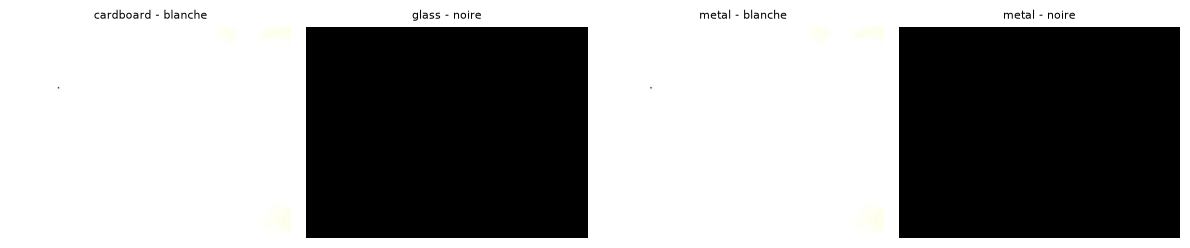

: 

In [ ]:
vides = df[df["vide"]]
n = len(vides)
if n > 0:
    plt.figure(figsize=(3 * min(n, 5), 3 * ((n - 1) // 5 + 1)))
    for i, (_, ligne) in enumerate(vides.iterrows()):
        plt.subplot((n - 1) // 5 + 1, min(n, 5), i + 1)
        plt.imshow(Image.open(ligne["chemin"]).convert("RGB"))
        plt.title(f"{ligne['classe']} - {ligne['type_vide']}", fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()